In [7]:
%%bash
# This block runs as a single shell script, so variables persist within this block

# Create directories
mkdir -p $CONDA_PREFIX/etc/conda/activate.d
mkdir -p $CONDA_PREFIX/etc/conda/deactivate.d

# Define the dynamic finding command
FIND_CMD='$(find $CONDA_PREFIX/lib/python*/site-packages/nvidia -name lib -type d | paste -sd ":" -)'

# Write the activation script
echo "export OLD_LD_LIBRARY_PATH=\$LD_LIBRARY_PATH" > $CONDA_PREFIX/etc/conda/activate.d/env_vars.sh
echo "export LD_LIBRARY_PATH=\$LD_LIBRARY_PATH:$FIND_CMD" >> $CONDA_PREFIX/etc/conda/activate.d/env_vars.sh

# Write the deactivation script
echo "export LD_LIBRARY_PATH=\$OLD_LD_LIBRARY_PATH" > $CONDA_PREFIX/etc/conda/deactivate.d/env_vars.sh
echo "unset OLD_LD_LIBRARY_PATH" >> $CONDA_PREFIX/etc/conda/deactivate.d/env_vars.sh

echo "Activation scripts created successfully at $CONDA_PREFIX/etc/conda/activate.d/env_vars.sh"


Activation scripts created successfully at /home/sonic/anaconda3/envs/jax_flow/etc/conda/activate.d/env_vars.sh


In [8]:
import os
import glob
import sys
import ctypes

# 1. Find the library paths (Your existing logic)
conda_prefix = sys.prefix
# We use recursive globbing to match the 'find' command logic more robustly
nvidia_lib_dirs = glob.glob(os.path.join(conda_prefix, 'lib', 'python*', 'site-packages', 'nvidia', '*', 'lib'))

# 2. Update LD_LIBRARY_PATH (For any subprocesses JAX might spawn)
current_ld = os.environ.get('LD_LIBRARY_PATH', '')
os.environ['LD_LIBRARY_PATH'] = f"{current_ld}:{':'.join(nvidia_lib_dirs)}"

# 3. CRITICAL FIX: Manually pre-load the libraries
# Since we can't update the linker cache at runtime, we use ctypes to load
# the drivers directly into the process memory space.
loaded_count = 0
# We explicitly look for common cuda libs to ensure they are loaded
target_libs = ["libcusparse.so", "libcublas.so", "libcudnn.so", "libcufft.so", "libcusolver.so"]

for lib_dir in nvidia_lib_dirs:
    # Find all .so files in these directories
    for lib_path in glob.glob(os.path.join(lib_dir, "lib*.so*")):
        try:
            # RTLD_GLOBAL makes symbols available to subsequent libraries (like JAX)
            ctypes.CDLL(lib_path, mode=ctypes.RTLD_GLOBAL)
            loaded_count += 1
        except OSError:
            # Ignore load errors (e.g. if a lib is missing dependencies, others might still work)
            continue

print(f"Success: Manually pre-loaded {loaded_count} NVIDIA shared libraries.")

# 4. NOW import JAX
import jax
print("JAX Devices:", jax.devices())


Success: Manually pre-loaded 58 NVIDIA shared libraries.
JAX Devices: [CudaDevice(id=0), CudaDevice(id=1)]


In [9]:
import os
import json
import pickle
import functools
import numpy as np
# import jax
# import jax.numpy as np
import hydra
from etils import epath
from omegaconf import OmegaConf, open_dict
from brax.training.acme import running_statistics
import argparse
import flax
from pathlib import Path  # Needed for checking Path objects
import matplotlib.pyplot as plt
# --- Local Imports ---
from helper import parse_cfg
from custom_envs import registry, dm_control_suite, locomotion
from learning.agents.ppo import networks as ppo_networks
from learning.configs import dm_control_training_config, locomotion_training_config
from learning.module.wrapper.adv_wrapper import wrap_for_adv_training
from learning.module.wrapper.evaluator import AdvEvaluator
from learning.agents.sampler_ppo import networks as samplerppo_networks
# --- HELPER: Robust JSON Encoder (Fixed for NumPy 2.0) ---
import jax
import jax.numpy as jnp
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["CUDA_VISIBLE_DEVICES"] = '0'


In [10]:

from custom_envs.dm_control_suite import get_default_config, load


cfg_path= epath.Path(".").resolve()
print(cfg_path)
cfg_path = os.path.join(cfg_path, "config.yaml")
# cfg = compose(config_name="config.yaml")
cfg = OmegaConf.load(cfg_path)
cfg.task="CartpoleSwingup"
cfg.policy="gmmppo"
cfg.seed=103
cfg.beta=-10
env_name='CartpoleSwingup'
env_cfg = get_default_config(env_name)
env = load(env_name, env_cfg)
cfg = parse_cfg(cfg)
if cfg.policy == "epoptppo":
    cfg.work_dir = cfg.work_dir / f"epsilon={cfg.epsilon}"
elif cfg.policy == "flowppo":
    cfg.work_dir = cfg.work_dir / f"beta={cfg.beta}_gamma={cfg.gamma}"
elif cfg.policy == "gmmppo":
    cfg.work_dir = cfg.work_dir / f"beta={cfg.beta}"
elif cfg.policy == "adrppo":
    cfg.work_dir = cfg.work_dir / f"threshold={cfg.success_threshold}"
elif cfg.policy == "doraemonppo":
    cfg.work_dir = cfg.work_dir / f"threshold={cfg.success_threshold}_condition={cfg.success_rate_condition}"
if cfg.policy=='ppo_nodr':
    sampler_choice = 'NODR'
elif cfg.policy=='ppo':
    sampler_choice = 'UDR'
elif cfg.policy=='epoptppo':
    sampler_choice = 'EPOpt'
elif cfg.policy=='flowppo':
    sampler_choice = 'FLOW_NS'
elif cfg.policy=='gmmppo':
    sampler_choice = 'GMM'
result_dir = cfg.work_dir / "results" /sampler_choice
low, high = env.dr_range
# print("result dir", result_dir)

# files = list(result_dir.glob("samples_*.npy"))

# # Sort numerically by splitting the stem (filename without extension)
# # This assumes the format is strictly "samples_{number}"
# files.sort(key=lambda f: int(f.stem.split('_')[-1]))

# # Load
# samples = np.load(files[-1])#{f.stem: np.load(f) for f in files}

# files = list(result_dir.glob("logq_*.npy"))

# # Sort numerically by splitting the stem (filename without extension)
# # This assumes the format is strictly "samples_{number}"
# files.sort(key=lambda f: int(f.stem.split('_')[-1]))

# # Load
# logq = np.load(files[-1])#{f.stem: np.load(f) for f in files}
# low, high = env.dr_range


/home/sonic/tjrjcf410/adverserial_sampler_for_rl/learning


In [11]:
from learning.eval_nonstationary import load_sampler_state


print("\n[LANGEVIN] Pre-loading GMM state...")

factory_args = {
    "observation_size": env.observation_size,
    "action_size": env.action_size,
    "dynamics_param_size": len(low),
    "batch_size": 1, "num_envs": 1,
    "bound_info": (low, high),
    "preprocess_observations_fn" : running_statistics.normalize,
    "success_threshold": 0.6, "success_rate_condition": 0.5,
    "sampler_choice": "GMM", 
}

file_path = f"{result_dir}/checkpoints/sampler_state_latest.msgpack"
try:
    sampler_net, gmm_state = load_sampler_state(file_path, "GMM", factory_args)
    actual_gmm_state = gmm_state.model_state.gmm_state
    
    log_prob_fn =  jax.vmap(functools.partial(sampler_net.gmm_network.model.log_density,\
                  gmm_state=actual_gmm_state))
    
    print("GMM State loaded.")
except Exception as e:
    print(f"[ERROR] Failed to load GMM: {e}")
    exit(1)



[LANGEVIN] Pre-loading GMM state...
num envs 1
batch size 1
GMM State loaded.


result dir /home/sonic/tjrjcf410/adverserial_sampler_for_rl/learning/logs/CartpoleSwingup/103/gmmppo/beta=-10/results/GMM


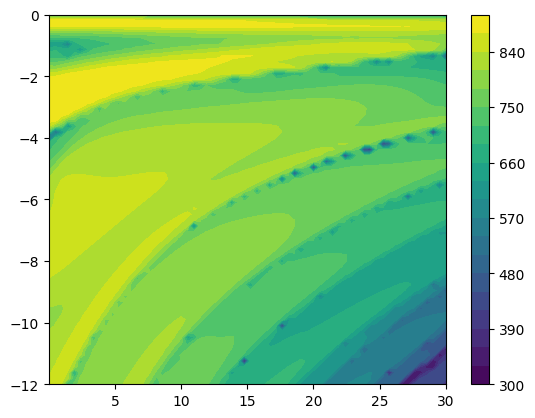

In [42]:
print("result dir", result_dir)

files = list(result_dir.glob("reward_1d*.npy"))
fig = plt.figure()
ax = fig.add_subplot()
rewards = np.load(files[-1])
x, y = np.meshgrid(np.linspace(low[0], high[0], 64), np.linspace(low[1], high[1], 64))
grid = np.c_[x.ravel(), y.ravel()]
pdf_values = jnp.reshape(rewards, x.shape)
ctf = plt.contourf(x, y, pdf_values, levels=20, cmap='viridis')
cbar = fig.colorbar(ctf)#, location="bottom")
handles= []


/tmp/ipykernel_4121450/3007432436.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('Reds')(np.linspace(0.4, 1.0, num_walks))


Simulating 4 Solid Paths...


/home/sonic/anaconda3/envs/jax_flow/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


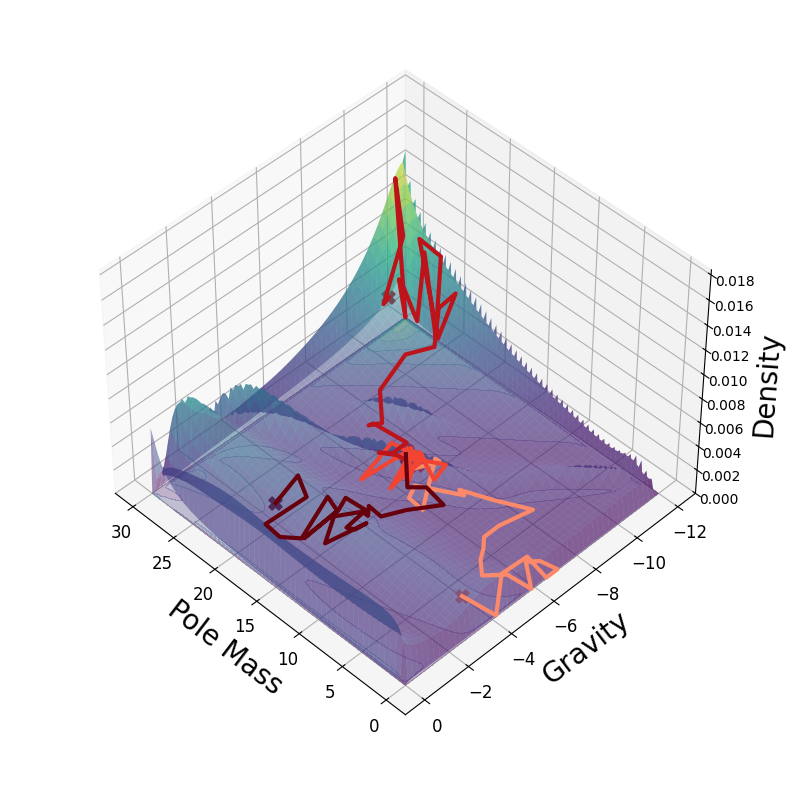

In [41]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.cm as cm

def plot_langevin_3d_solid_fixed(log_prob_fn, low, high, key, num_walks=3):
    # 1. Setup Surface
    resolution = 100
    x = np.linspace(low[0], high[0], resolution)
    y = np.linspace(low[1], high[1], resolution)
    X, Y = np.meshgrid(x, y)
    grid_flat = np.c_[X.ravel(), Y.ravel()]
    
    # Calculate PDF
    try:
        log_pdf_vals = log_prob_fn(sample=grid_flat)
    except TypeError:
        log_pdf_vals = log_prob_fn(grid_flat)
    
    pdf_values = jnp.exp(log_pdf_vals)
    Z = np.array(pdf_values).reshape(X.shape)
    max_z = np.max(Z)

    # 2. Setup Figure
    fig = plt.figure(figsize=(25, 10), layout='constrained')
    ax = fig.add_subplot(111, projection='3d')
    ax.view_init(elev=45, azim=135)

    # Plot Surface (Background)
    # zorder=1 ensures this is drawn first (at the bottom)
    surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.5, zorder=1)
    
    # Floor projection (Shadow)
    ax.contourf(X, Y, Z, zdir='z', offset=0, cmap='viridis', alpha=0.3, zorder=1)

    # 3. Simulation Loop
    n_steps = 25
    drift_scale = 0.05
    rw_scale = 0.05
    param_range = jnp.array(high) - jnp.array(low)
    grad_fn = jax.jit(jax.grad(lambda p: log_prob_fn(sample=p[None, :])[0]))
    
    # Use 'tab10' for distinct solid colors
    colors = cm.get_cmap('Reds')(np.linspace(0.4, 1.0, num_walks))

    print(f"Simulating {num_walks} Solid Paths...")

    for i in range(num_walks):
        key, walk_key = jax.random.split(key)
        
        # Jitter start
        start_noise = jax.random.normal(walk_key, shape=(2,)) * 0.05
        current_pos = jnp.array([(low[0] + high[0])/2, (low[1] + high[1])/2]) + start_noise
        
        walk_path = [current_pos]

        for _ in range(n_steps):
            walk_key, subkey = jax.random.split(walk_key)
            grads = grad_fn(current_pos)
            grad_norm = jnp.linalg.norm(grads) + 1e-6
            normalized_grads = grads / grad_norm
            drift_term = normalized_grads * drift_scale * param_range
            noise_term = jax.random.normal(subkey, shape=current_pos.shape) * rw_scale * param_range
            next_pos = jnp.clip(current_pos + drift_term + noise_term, jnp.array(low), jnp.array(high))
            walk_path.append(next_pos)
            current_pos = next_pos
        
        walk_path = np.array(walk_path)

        
        # 1. Calculate base height
        walk_log_probs = log_prob_fn(sample=walk_path)
        base_z = np.exp(walk_log_probs)
        
        # 2. Lift the colored line significantly (+20% of max height)
        # This physically separates it from the semi-transparent surface
        floating_z = base_z# + (max_z * 0.01) + (i * 0.005)
        # base_z
        c = (colors[i][0], colors[i][1], colors[i][2], 1.0) 
        
        # A. Plot the "Floating" Solid Line (The main visual)
        ax.plot(walk_path[:, 0], walk_path[:, 1], floating_z, 
                color=c, linewidth=3.0, alpha=1.0, zorder=100, label=f'Adversarial Traj {i+1}')
        
        ax.scatter(walk_path[0, 0], walk_path[0, 1], floating_z[0], 
                   color=c, marker='o', s=60, alpha=1.0, zorder=100)
        ax.scatter(walk_path[-1, 0], walk_path[-1, 1], floating_z[-1], 
                   color=c, marker='X', s=90, alpha=1.0, zorder=100)

        # B. Plot the "Shadow" on the actual surface (Thin, darker line)
        # This helps the eye connect the floating line to the actual hill
        ax.plot(walk_path[:, 0], walk_path[:, 1], base_z, 
                color='black', linewidth=1.0, alpha=0.3, zorder=5)

    # Styling
    # ax.set_title(f"Adversarial Nonstationary Random Walk on Density Landscape", fontsize=15)
    if hasattr(env, 'dr_label'):
        xlabel, ylabel = env.dr_label
    # Option B: Hardcode for Cartpole
    else:
        xlabel, ylabel = "Pole Mass", "Gravity"
    ax.set_xlabel(xlabel, fontsize=20, labelpad=10)
    ax.set_ylabel(ylabel, fontsize=20, labelpad=10)
    ax.set_zlabel("Density", fontsize=20, labelpad=10)
    ax.set_zlim(0, max_z * 1.3)
    ax.set_box_aspect(None, zoom=0.85)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    # ax.legend(loc='upper right', bbox_to_anchor=(1.1, .9), fontsize=20)
    # plt.subplots_adjust(left=0.05, right=.9, top=0.95, bottom=0.05)
    plt.show()

# --- Execution ---
key = jax.random.PRNGKey(14)
plot_langevin_3d_solid_fixed(log_prob_fn, low, high, key, num_walks=4)
